# **demand estimation and market analysis: air fryers**

note book 1 - data analysis
role - making the data worth reading, visual, and readable before building a model

In [15]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='tab10')
COLORS = sns.color_palette('tab10', 10)
BRANDS = ['chefman','cosori','cuisinart','dash','gowise usa',
          'instant_pot','ninja','nuwave','oster','ultrean']
BRAND_PALETTE = {b: COLORS[i] for i, b in enumerate(BRANDS)}

df = pd.read_csv('air_fryers_clean_brand_year.csv')
print(df.shape)
print(df['brand'].unique())
print(df['year'].unique())


(50, 15)
['chefman' 'cosori' 'cuisinart' 'dash' 'gowise usa' 'instant_pot' 'ninja'
 'nuwave' 'oster' 'ultrean']
[2019 2020 2021 2022 2023]


1.1 verifying brands and years 2019-2023


In [16]:
print("Brands:", sorted(df['brand'].unique()))
print("Years:", sorted(df['year'].unique()))
print("Shares sum to 1 each year:")
print(df.groupby('year')['brand_share'].sum().round(6))


Brands: ['chefman', 'cosori', 'cuisinart', 'dash', 'gowise usa', 'instant_pot', 'ninja', 'nuwave', 'oster', 'ultrean']
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Shares sum to 1 each year:
year
2019    1.0
2020    1.0
2021    1.0
2022    1.0
2023    1.0
Name: brand_share, dtype: float64


Answer: the dataset contains exactly 10 brands which are chefman, cosori, cuisinart dash, gowise usa, instant_pot, ninja, nuwave, oster, ultrean. and spans the years 2019 through 2023 as required. brand shares sum to 1.0 within each year, confirming that the long tail brands have been properly dropped and shares recomputed.

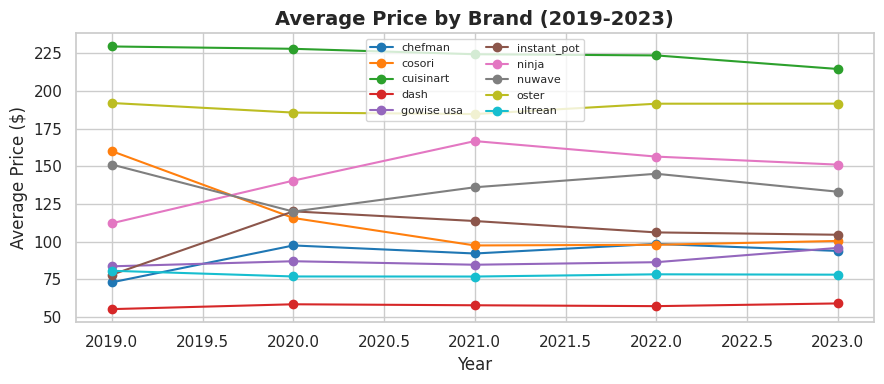

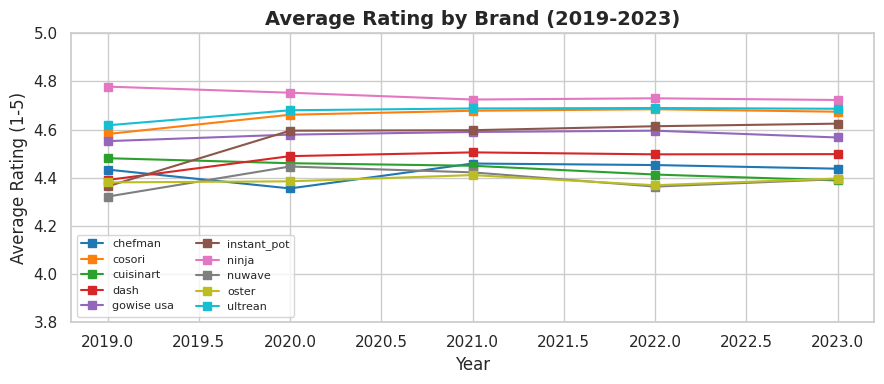

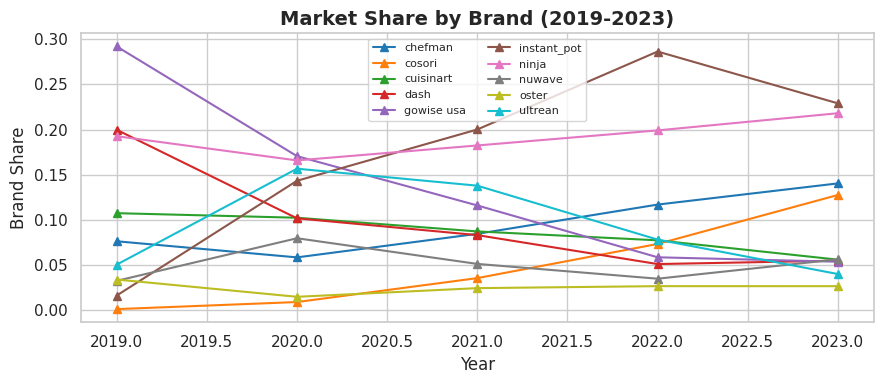

In [17]:
char_cols = ['compact_share','dual_basket_share','oven_style_share','rotisserie_share','window_share']

# --- Price ---
fig, ax = plt.subplots(figsize=(9,4))
for brand, grp in df.groupby('brand'):
    ax.plot(grp['year'], grp['avg_price'], marker='o', label=brand, color=BRAND_PALETTE[brand])
ax.set_title('Average Price by Brand (2019-2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Average Price ($)')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout(); plt.show()

# --- Rating ---
fig, ax = plt.subplots(figsize=(9,4))
for brand, grp in df.groupby('brand'):
    ax.plot(grp['year'], grp['avg_rating'], marker='s', label=brand, color=BRAND_PALETTE[brand])
ax.set_title('Average Rating by Brand (2019-2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Average Rating (1-5)'); ax.set_ylim(3.8, 5.0)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout(); plt.show()

# --- Market share ---
fig, ax = plt.subplots(figsize=(9,4))
for brand, grp in df.groupby('brand'):
    ax.plot(grp['year'], grp['brand_share'], marker='^', label=brand, color=BRAND_PALETTE[brand])
ax.set_title('Market Share by Brand (2019-2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Brand Share')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout(); plt.show()


1.3 product characteristics

In [18]:
char_cols = ['compact_share','dual_basket_share','oven_style_share','rotisserie_share','window_share']
char_means = df.groupby('brand')[char_cols].mean()
char_means.columns = ['Compact','Dual Basket','Oven Style','Rotisserie','Window']
print("Overall means:")
print(df[char_cols].mean().rename({'compact_share':'Compact','dual_basket_share':'Dual Basket',
    'oven_style_share':'Oven Style','rotisserie_share':'Rotisserie','window_share':'Window'}).round(3))
print()
print("By brand:")
print(char_means.round(3))


Overall means:
Compact        0.980
Dual Basket    0.002
Oven Style     0.563
Rotisserie     0.071
Window         0.037
dtype: float64

By brand:
             Compact  Dual Basket  Oven Style  Rotisserie  Window
brand                                                            
chefman        0.962        0.013       0.597       0.370   0.363
cosori         0.997        0.000       0.030       0.024   0.000
cuisinart      0.996        0.000       0.913       0.000   0.000
dash           0.999        0.000       0.890       0.000   0.000
gowise usa     1.000        0.000       0.184       0.184   0.001
instant_pot    0.860        0.000       0.675       0.102   0.003
ninja          0.992        0.002       0.100       0.000   0.000
nuwave         0.995        0.007       0.543       0.027   0.000
oster          1.000        0.000       0.865       0.000   0.000
ultrean        1.000        0.000       0.830       0.000   0.000


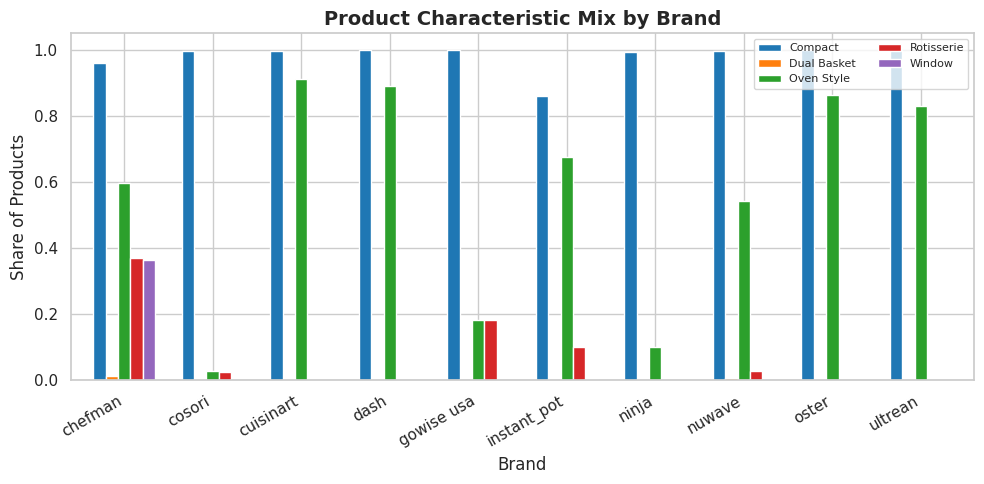

In [19]:
fig, ax = plt.subplots(figsize=(10,5))
char_means.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Product Characteristic Mix by Brand', fontsize=14, fontweight='bold')
ax.set_xlabel('Brand'); ax.set_ylabel('Share of Products')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(loc='upper right', ncol=2, fontsize=8)
fig.tight_layout(); plt.show()


which features are common?

compact design is by far the most common feature wiht a mean share of about 0.98, meaning nearly every product across all brands is classified as compact. Oven style products are the second most common feature, appearing in about 56% of products on average.

Which features are rare?

Dual basket products are extremely rare with a mean share near 0.002, essentially absent from this market during this period. window and rottiserie features are also uncommon at about 3.7% and 7.1% mean shares respectively.

Brand specialization? Chefman stnads out for having a meaningful share of both rotisserrie (37%) and window (36%) products, making it the most differeientiated brand in terms of product type variety. Cuisinart and dash are almost entirely compact focused with little diversity. Gowise USA and oster are 100% compact across all years. Instant pot has a notable rotisserie share (10%) and a lower compact share (86%), indicating some product diversity. most other brands are overhemingly compact focused.

# **Market decsription**

Market description: th eair fryer market from 2019 to 2023 is dominated by a handful of strong brands iwth ninja consistently holding the largest share, growing from around 17% to 29% by 2023, making it the clear market leader. Cuisinart and oster occupy the premium price tier at 224 and 189 on average respectively while dash is the clear budget leader at 57$ average price and large but declining share. Cosori entered with a very small 2019 share but grew dramatically through 2021, suggesting rapid consumer adoption while older mid tier brands like nuWave and Gowise USA have experieinced declining or stagnant shares. Average rating across all brands are tightly clustered between about 4.2 and 4.7 throughout the period with no dramatic quality differentiators visible from ratings alone, suggesting consumers are largely satisfied across the board. The market shows some turbulence rather than perfect stability as Cosori's rapid rise and Gowise USA's decline indicate shifts in consumer prefernces and possibly product innovation cycles, but ninja's dominance has been increasingly entrenched over time. Overall the market is a mix of budget-friendly compact only brands and more expensive feature rich or premium brands, with the majority of market share flowing toward brands that balance acceptable prices with brand recoginition.